In [1]:
#
# This is a sample Notebook to demonstrate how to read "MNIST Dataset"
#
import numpy as np # linear algebra
import struct
from array import array
from os.path  import join

#
# MNIST Data Loader Class
#
class MnistDataloader(object):
    def __init__(self, training_images_filepath,training_labels_filepath,
                 test_images_filepath, test_labels_filepath):
        self.training_images_filepath = training_images_filepath
        self.training_labels_filepath = training_labels_filepath
        self.test_images_filepath = test_images_filepath
        self.test_labels_filepath = test_labels_filepath
    
    def read_images_labels(self, images_filepath, labels_filepath):        
        labels = []
        with open(labels_filepath, 'rb') as file:
            magic, size = struct.unpack(">II", file.read(8))
            if magic != 2049:
                raise ValueError('Magic number mismatch, expected 2049, got {}'.format(magic))
            labels = array("B", file.read())        
        
        with open(images_filepath, 'rb') as file:
            magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
            if magic != 2051:
                raise ValueError('Magic number mismatch, expected 2051, got {}'.format(magic))
            image_data = array("B", file.read())        
        images = []
        for i in range(size):
            images.append([0] * rows * cols)
        for i in range(size):
            img = np.array(image_data[i * rows * cols:(i + 1) * rows * cols])
            img = img.reshape(28, 28)
            images[i][:] = img            
        
        return images, labels
            
    def load_data(self):
        x_train, y_train = self.read_images_labels(self.training_images_filepath, self.training_labels_filepath)
        x_test, y_test = self.read_images_labels(self.test_images_filepath, self.test_labels_filepath)
        return (x_train, y_train),(x_test, y_test)

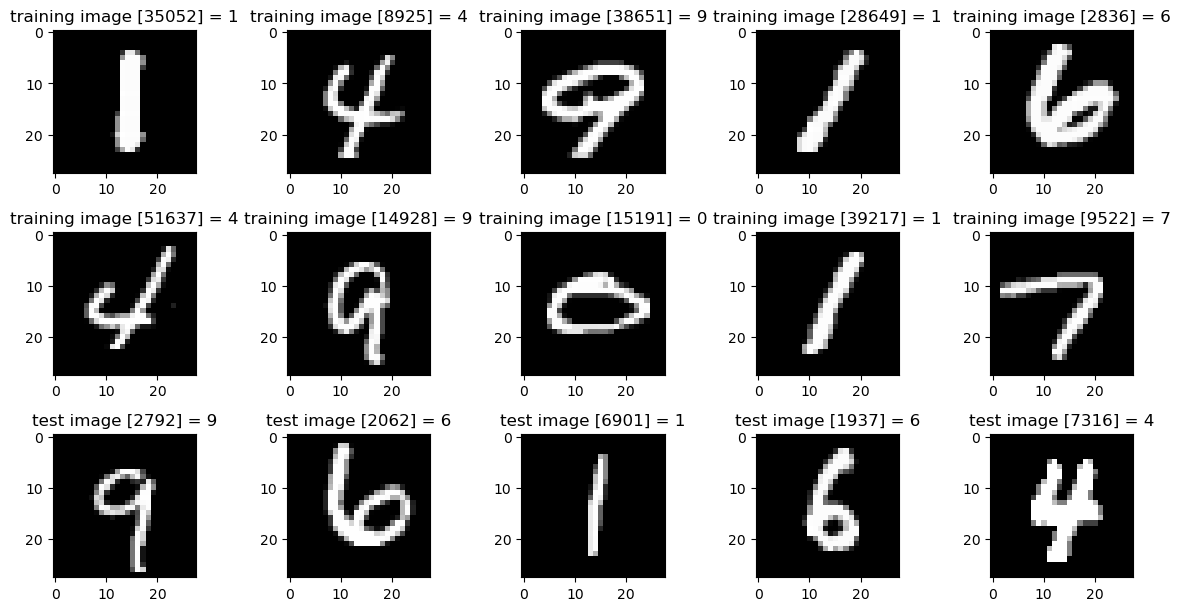

In [2]:
#
# Verify Reading Dataset via MnistDataloader class
#
%matplotlib inline
import random
import matplotlib.pyplot as plt

#
# Set file paths based on added MNIST Datasets
#
input_path = 'MNIST_data'
training_images_filepath = join(input_path, "train-images.idx3-ubyte")
training_labels_filepath = join(input_path, "train-labels.idx1-ubyte")
test_images_filepath = join(input_path, "t10k-images.idx3-ubyte")
test_labels_filepath = join(input_path, "t10k-labels.idx1-ubyte")

#
# Load MINST dataset
#
mnist_dataloader = MnistDataloader(training_images_filepath, training_labels_filepath, test_images_filepath, test_labels_filepath)
(x_train, y_train), (x_test, y_test) = mnist_dataloader.load_data()

x_train = np.array(x_train).reshape(-1, 28, 28)
x_test = np.array(x_test).reshape(-1, 28, 28)
y_train = np.array(y_train)
y_test = np.array(y_test)

def show_images(images, title_texts):
    cols = 5
    rows = int(len(images)/cols) + 1
    plt.figure(figsize=(12, 8))  # smaller figure so it displays better
    index = 1    
    for image, title_text in zip(images, title_texts):        
        plt.subplot(rows, cols, index)        
        plt.imshow(image, cmap=plt.cm.gray)
        if title_text != '':
            plt.title(title_text, fontsize=12)        
        index += 1
    plt.tight_layout()
    plt.show()

# Select some random images to show
images_2_show = []
titles_2_show = []

for i in range(10):
    r = random.randint(0, len(x_train)-1)
    images_2_show.append(x_train[r])
    titles_2_show.append(f'training image [{r}] = {y_train[r]}')

for i in range(5):
    r = random.randint(0, len(x_test)-1)
    images_2_show.append(x_test[r])
    titles_2_show.append(f'test image [{r}] = {y_test[r]}')

show_images(images_2_show, titles_2_show)


In [3]:
from sklearn.linear_model import LogisticRegression

# Use multinomial loss with a solver that supports it
clf = LogisticRegression(
    multi_class='multinomial',
    solver='saga',     # saga or lbfgs are good for large datasets
    max_iter=500,      # may need to increase to ensure convergence
    verbose=1          # optional, shows training progress
)

In [4]:
n_samples, h, w = x_train.shape
x_train_flat = x_train.reshape(n_samples, h*w)
x_test_flat = x_test.reshape(x_test.shape[0], h*w)

In [5]:
clf.fit(x_train_flat, y_train)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


max_iter reached after 539 seconds


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(max_iter=500, multi_class='multinomial', solver='saga',
                   verbose=1)

In [6]:
from sklearn.metrics import accuracy_score

y_pred = clf.predict(x_test_flat)
print("Test accuracy:", accuracy_score(y_test, y_pred))

Test accuracy: 0.9241


COMPUTATIONAL COMPLEXITY ANALYSIS - SOFTMAX REGRESSION

Testing dataset sizes: [1000, 5000, 10000, 20000, 40000, 60000]
Total training samples available: 60000
Test set size: 10000


Training with N = 1,000 samples
Starting training...


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Training time: 8.597 seconds
Test accuracy: 0.8506 (85.06%)
Iterations used: 500

Training with N = 5,000 samples
Starting training...


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Training time: 46.023 seconds
Test accuracy: 0.8819 (88.19%)
Iterations used: 500

Training with N = 10,000 samples
Starting training...


...

Training time: 174.848 seconds
Test accuracy: 0.9045 (90.45%)
Iterations used: 500

Training with N = 40,000 samples
Starting training...


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Training time: 352.983 seconds
Test accuracy: 0.9193 (91.93%)
Iterations used: 500

Training with N = 60,000 samples
Starting training...


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Training time: 527.717 seconds
Test accuracy: 0.9240 (92.40%)
Iterations used: 500

SUMMARY OF RESULTS
    N  training_time  accuracy  iterations_used
 1000       8.597141    0.8506              500
 5000      46.022759    0.8819              500
10000      87.827341    0.8886              500
20000     174.848013    0.9045              500
40000     352.982503    0.9193              500
60000     527.717319    0.9240              500


Computational Complexity Analysis:
Training time follows approximately: T ≈ 0.008687 × N^1.002
Time complexity: O(N^1.002)


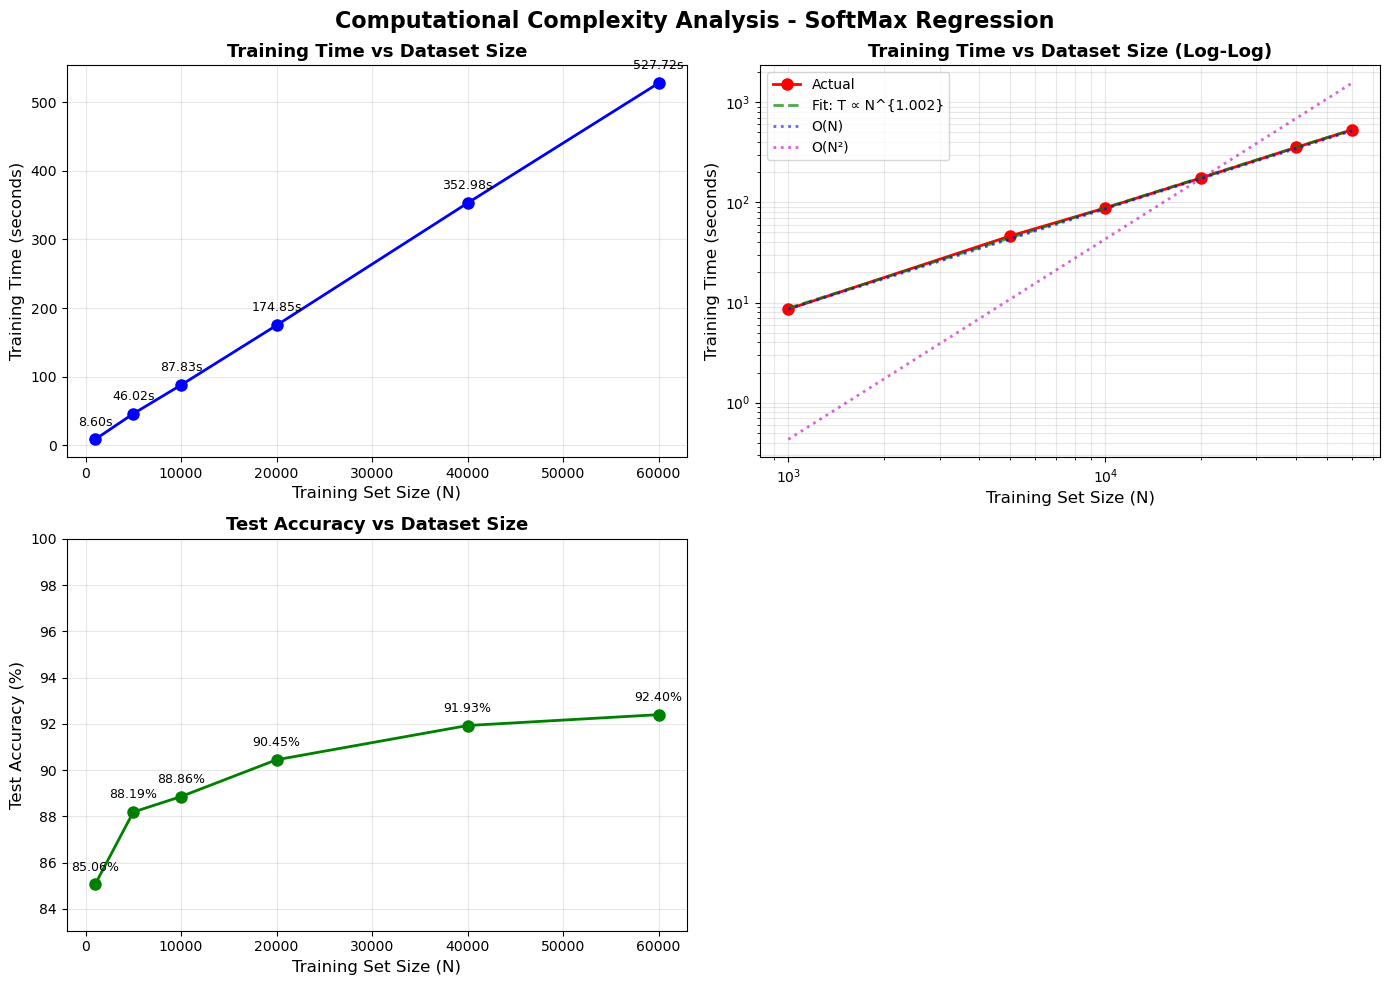


KEY INSIGHTS
1. Training time increases from 8.597s (N=1,000)
   to 527.717s (N=60,000)
   - Speedup factor: 61.4x slower

2. Accuracy improves from 85.06% (N=1,000)
   to 92.40% (N=60,000)
   - Improvement: 7.34 percentage points

3. Time complexity is approximately O(N^1.002)
   - This is better than quadratic, indicating efficient scaling

4. Diminishing returns in accuracy:
   - Largest accuracy gain: 3.130% (early training)
   - Smallest accuracy gain: 0.470% (later training)


In [ ]:
# ============================================================================
# COMPUTATIONAL COMPLEXITY ANALYSIS - SOFTMAX REGRESSION
# ============================================================================

import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd

# Dataset sizes to test
N_sizes = [1000, 5000, 10000, 20000, 40000, 60000]

# Store results
results = {
    'N': [],
    'training_time': [],
    'accuracy': [],
    'iterations_used': []
}

print("=" * 70)
print("COMPUTATIONAL COMPLEXITY ANALYSIS - SOFTMAX REGRESSION")
print("=" * 70)
print(f"\nTesting dataset sizes: {N_sizes}")
print(f"Total training samples available: {len(x_train_flat)}")
print(f"Test set size: {len(x_test_flat)}\n")

# Run experiments for each dataset size
for N in N_sizes:
    print(f"\n{'='*70}")
    print(f"Training with N = {N:,} samples")
    print(f"{'='*70}")
    
    # Subset the training data
    X_train_subset = x_train_flat[:N]
    y_train_subset = y_train[:N]
    
    # Initialize the model
    clf = LogisticRegression(
        multi_class='multinomial',
        solver='saga',
        max_iter=500,
        verbose=0,  # Turn off verbose for cleaner output
        random_state=42  # For reproducibility
    )
    
    # Measure training time
    print(f"Starting training...")
    start_time = time.time()
    clf.fit(X_train_subset, y_train_subset)
    training_time = time.time() - start_time
    
    # Make predictions on test set
    y_pred = clf.predict(x_test_flat)
    accuracy = accuracy_score(y_test, y_pred)
    
    # Store results
    results['N'].append(N)
    results['training_time'].append(training_time)
    results['accuracy'].append(accuracy)
    results['iterations_used'].append(clf.n_iter_[0] if hasattr(clf, 'n_iter_') else None)
    
    print(f"Training time: {training_time:.3f} seconds")
    print(f"Test accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    if hasattr(clf, 'n_iter_'):
        print(f"Iterations used: {clf.n_iter_[0]}")

# Create DataFrame for easy viewing
df_results = pd.DataFrame(results)

print("\n" + "=" * 70)
print("SUMMARY OF RESULTS")
print("=" * 70)
print(df_results.to_string(index=False))
print()

# Calculate time complexity (fit to power law: T = aN^b)
log_N = np.log(results['N'])
log_T = np.log(results['training_time'])
coeffs = np.polyfit(log_N, log_T, 1)
b = coeffs[0]  # Exponent in the power law
a = np.exp(coeffs[1])  # Coefficient

print(f"\nComputational Complexity Analysis:")
print(f"Training time follows approximately: T ≈ {a:.6f} × N^{b:.3f}")
print(f"Time complexity: O(N^{b:.3f})")

# Create visualizations - FIXED: Changed to 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Computational Complexity Analysis - SoftMax Regression', 
             fontsize=16, fontweight='bold')

# Plot 1: Training Time vs Dataset Size (Linear scale)
ax1 = axes[0, 0]
ax1.plot(results['N'], results['training_time'], 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Training Set Size (N)', fontsize=12)
ax1.set_ylabel('Training Time (seconds)', fontsize=12)
ax1.set_title('Training Time vs Dataset Size', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
for i, (n, t) in enumerate(zip(results['N'], results['training_time'])):
    ax1.annotate(f'{t:.2f}s', (n, t), textcoords="offset points", 
                xytext=(0,10), ha='center', fontsize=9)

# Plot 2: Training Time vs Dataset Size (Log-Log scale)
ax2 = axes[0, 1]
ax2.loglog(results['N'], results['training_time'], 'ro-', linewidth=2, 
          markersize=8, label='Actual')

# Add fitted line
N_fit = np.array(results['N'])
T_fit = a * (N_fit ** b)
ax2.loglog(N_fit, T_fit, 'g--', linewidth=2, alpha=0.7, 
          label=f'Fit: T ∝ N^{{{b:.3f}}}')

# Add O(N) and O(N^2) reference lines
# Scale them to pass through a middle point for better visualization
N_ref = np.array(results['N'])
mid_idx = len(results['N']) // 2
scale_factor = results['training_time'][mid_idx] / (N_ref[mid_idx] ** b)

# O(N) reference line
T_linear = scale_factor * N_ref
ax2.loglog(N_ref, T_linear, 'b:', linewidth=2, alpha=0.6, label='O(N)')

# O(N^2) reference line  
T_quadratic = scale_factor * (N_ref ** 2) / (N_ref[mid_idx])
ax2.loglog(N_ref, T_quadratic, 'm:', linewidth=2, alpha=0.6, label='O(N²)')

ax2.set_xlabel('Training Set Size (N)', fontsize=12)
ax2.set_ylabel('Training Time (seconds)', fontsize=12)
ax2.set_title('Training Time vs Dataset Size (Log-Log)', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, which='both')
ax2.legend(fontsize=10)

# Plot 3: Accuracy vs Dataset Size
ax3 = axes[1, 0]
ax3.plot(results['N'], [acc * 100 for acc in results['accuracy']], 
        'go-', linewidth=2, markersize=8)
ax3.set_xlabel('Training Set Size (N)', fontsize=12)
ax3.set_ylabel('Test Accuracy (%)', fontsize=12)
ax3.set_title('Test Accuracy vs Dataset Size', fontsize=13, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.set_ylim([min(results['accuracy'])*100 - 2, 100])
for i, (n, acc) in enumerate(zip(results['N'], results['accuracy'])):
    ax3.annotate(f'{acc*100:.2f}%', (n, acc*100), textcoords="offset points", 
                xytext=(0,10), ha='center', fontsize=9)

# Hide the unused 4th subplot
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

# Additional insights
print("\n" + "=" * 70)
print("KEY INSIGHTS")
print("=" * 70)
print(f"1. Training time increases from {results['training_time'][0]:.3f}s (N=1,000)")
print(f"   to {results['training_time'][-1]:.3f}s (N=60,000)")
print(f"   - Speedup factor: {results['training_time'][-1]/results['training_time'][0]:.1f}x slower")
print()
print(f"2. Accuracy improves from {results['accuracy'][0]*100:.2f}% (N=1,000)")
print(f"   to {results['accuracy'][-1]*100:.2f}% (N=60,000)")
print(f"   - Improvement: {(results['accuracy'][-1] - results['accuracy'][0])*100:.2f} percentage points")
print()
print(f"3. Time complexity is approximately O(N^{b:.3f})")
if b < 1.5:
    print(f"   - This is better than quadratic, indicating efficient scaling")
elif b < 2.5:
    print(f"   - This is approximately quadratic, typical for many ML algorithms")
else:
    print(f"   - This is super-quadratic, which may be a concern for very large datasets")
print()
print(f"4. Diminishing returns in accuracy:")
acc_gain = [(results['accuracy'][i+1] - results['accuracy'][i])*100 
            for i in range(len(results['accuracy'])-1)]
print(f"   - Largest accuracy gain: {max(acc_gain):.3f}% (early training)")
print(f"   - Smallest accuracy gain: {min(acc_gain):.3f}% (later training)")
